<a href="https://colab.research.google.com/github/ranimiftah12345678/ML_22_Ranimiftah/blob/main/JS05/JS05_TUGAS01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.
Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SequentialFeatureSelector
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Upload voice.csv ke Colab (ikon folder di kiri), atau pakai:
# from google.colab import files; files.upload()
df = pd.read_csv('voice.csv')

print(df.shape)
print(df['label'].value_counts())
print(df.isnull().sum().sum(), 'missing value')
df.head()

(3168, 21)
label
male      1584
female    1584
Name: count, dtype: int64
0 missing value


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Encode label & pisahkan fitur
y = df['label'].map({'female': 0, 'male': 1})
X = df.drop(columns='label')

# Split 80/20, stratified agar proporsi male/female terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline: semua fitur, k=5
base = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=5))])
base.fit(X_train, y_train)

print('Baseline (20 fitur, k=5)')
print('CV train :', cross_val_score(base, X_train, y_train, cv=cv).mean())
print('Test     :', accuracy_score(y_test, base.predict(X_test)))

Baseline (20 fitur, k=5)
CV train : 0.9696088749600456
Test     : 0.9763406940063092



2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

,fitur,F_score,mutual_info
0,meanfun,5697.873718,0.555423
1,IQR,1566.488204,0.449243
2,Q25,890.387180,0.406964
3,sp.ent,794.113490,0.170729
4,sd,750.762545,0.302449
5,sfm,375.206538,0.126971
6,centroid,324.436358,0.116538
7,meanfreq,324.436358,0.116538
8,median,218.279695,0.081538
9,mindom,100.408598,0.095199


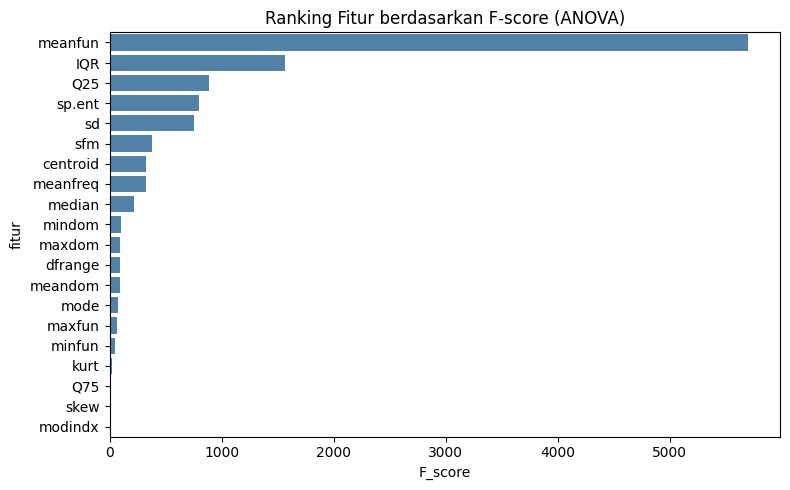

,fitur,F_score,mutual_info
0,meanfun,5697.873718,0.555423
1,IQR,1566.488204,0.449243
2,Q25,890.387180,0.406964
3,sp.ent,794.113490,0.170729
4,sd,750.762545,0.302449
5,sfm,375.206538,0.126971
6,centroid,324.436358,0.116538
7,meanfreq,324.436358,0.116538
8,median,218.279695,0.081538
9,mindom,100.408598,0.095199


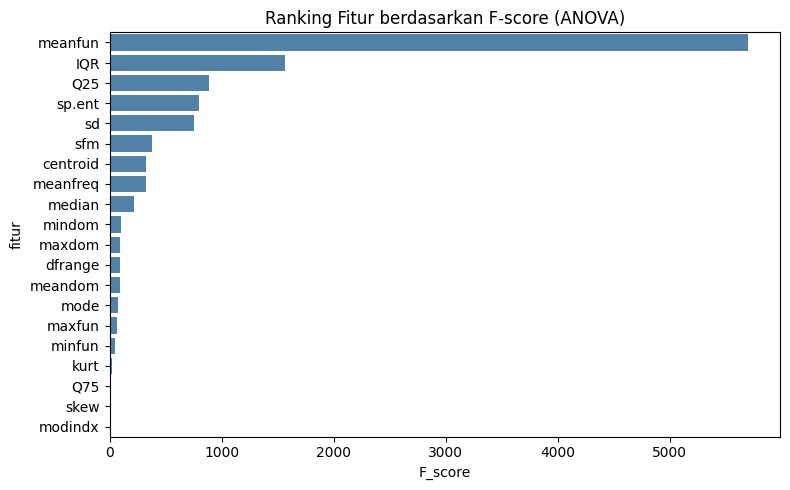

In [5]:
# Ranking fitur (hanya dari data train)
F, _ = f_classif(X_train, y_train)
MI = mutual_info_classif(X_train, y_train, random_state=42)

ranking = (pd.DataFrame({'fitur': X.columns, 'F_score': F, 'mutual_info': MI})
           .sort_values('F_score', ascending=False).reset_index(drop=True))
display(ranking)

plt.figure(figsize=(8, 5))
sns.barplot(data=ranking, y='fitur', x='F_score', color='steelblue')
plt.title('Ranking Fitur berdasarkan F-score (ANOVA)')
plt.tight_layout()
plt.show()

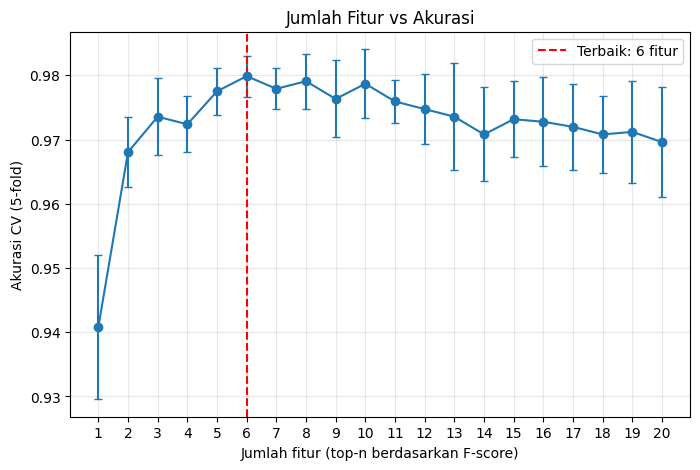

Metode A - 6 fitur terbaik: ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']


In [6]:
# Metode A: coba top-n fitur (n = 1..20), dievaluasi dengan CV
# SelectKBest ada DI DALAM pipeline, jadi tidak ada leakage
hasil_n = []
for n in range(1, X.shape[1] + 1):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('select', SelectKBest(f_classif, k=n)),
                     ('knn', KNeighborsClassifier(n_neighbors=5))])
    s = cross_val_score(pipe, X_train, y_train, cv=cv)
    hasil_n.append((n, s.mean(), s.std()))

hasil_n = pd.DataFrame(hasil_n, columns=['n_fitur', 'cv_mean', 'cv_std'])
best_n = int(hasil_n.loc[hasil_n['cv_mean'].idxmax(), 'n_fitur'])

plt.figure(figsize=(8, 5))
plt.errorbar(hasil_n['n_fitur'], hasil_n['cv_mean'], yerr=hasil_n['cv_std'], marker='o', capsize=3)
plt.axvline(best_n, color='red', ls='--', label=f'Terbaik: {best_n} fitur')
plt.xticks(range(1, 21))
plt.xlabel('Jumlah fitur (top-n berdasarkan F-score)')
plt.ylabel('Akurasi CV (5-fold)')
plt.title('Jumlah Fitur vs Akurasi')
plt.legend(); plt.grid(alpha=.3)
plt.show()

selector = SelectKBest(f_classif, k=best_n).fit(X_train, y_train)
fitur_A = list(X.columns[selector.get_support()])
print(f'Metode A - {best_n} fitur terbaik:', fitur_A)

In [7]:
# Metode B: Forward Selection (menambah fitur satu per satu selama akurasi naik)
sfs = SequentialFeatureSelector(
    Pipeline([('scaler', StandardScaler()),
              ('knn', KNeighborsClassifier(n_neighbors=5))]),
    n_features_to_select='auto', tol=0.001,
    direction='forward', scoring='accuracy', cv=cv, n_jobs=-1
)
sfs.fit(X_train, y_train)
fitur_B = list(X.columns[sfs.get_support()])
print('Metode B - fitur terpilih:', fitur_B)

Metode B - fitur terpilih: ['IQR', 'sfm', 'mode', 'meanfun']


In [8]:
# Bandingkan semua kandidat. Pemenang ditentukan dari CV (bukan dari test!)
kandidat = {
    'Semua fitur (20)': list(X.columns),
    f'SelectKBest (top-{best_n})': fitur_A,
    f'Forward Selection ({len(fitur_B)})': fitur_B,
}

rows = []
for nama, feats in kandidat.items():
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=5))])
    cv_acc = cross_val_score(pipe, X_train[feats], y_train, cv=cv).mean()
    test_acc = pipe.fit(X_train[feats], y_train).score(X_test[feats], y_test)
    rows.append({'Kandidat': nama, 'Jml fitur': len(feats), 'Akurasi CV': cv_acc, 'Akurasi Test': test_acc})

perbandingan = pd.DataFrame(rows)
display(perbandingan)

nama_terbaik = perbandingan.loc[perbandingan['Akurasi CV'].idxmax(), 'Kandidat']
fitur_final = kandidat[nama_terbaik]
print('\nFitur final:', nama_terbaik)
print(fitur_final)

,Kandidat,Jml fitur,Akurasi CV,Akurasi Test
0,Semua fitur (20),20,0.969609,0.976341
1,SelectKBest (top-6),6,0.979872,0.985804
2,Forward Selection (4),4,0.980663,0.988959



Fitur final: Forward Selection (4)
['IQR', 'sfm', 'mode', 'meanfun']


3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

k terbaik = 5 (akurasi CV = 0.9807)


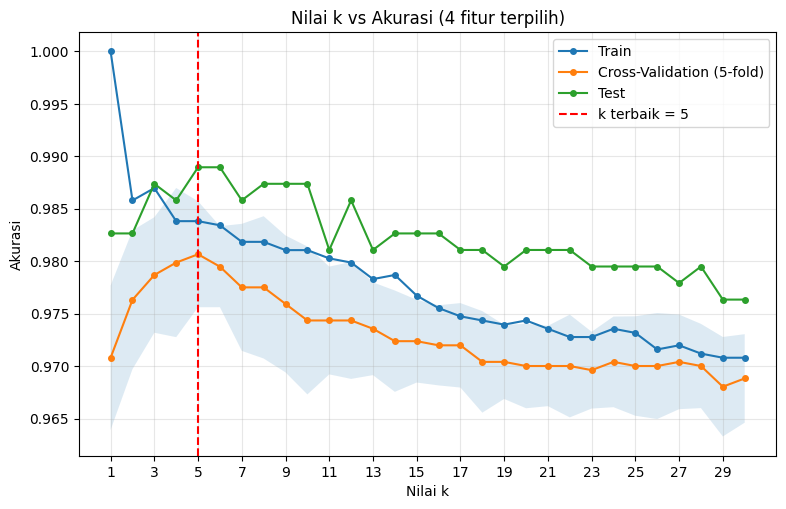

In [9]:
k_range = range(1, 31)
cv_mean, cv_std, acc_tr, acc_te = [], [], [], []

for k in k_range:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=k))])
    s = cross_val_score(pipe, X_train[fitur_final], y_train, cv=cv)
    cv_mean.append(s.mean()); cv_std.append(s.std())
    pipe.fit(X_train[fitur_final], y_train)
    acc_tr.append(pipe.score(X_train[fitur_final], y_train))
    acc_te.append(pipe.score(X_test[fitur_final], y_test))

cv_mean, cv_std = np.array(cv_mean), np.array(cv_std)

# k terbaik = CV tertinggi; jika seri, ambil k terbesar (model lebih stabil)
best_k = list(k_range)[np.where(cv_mean == cv_mean.max())[0][-1]]
print(f'k terbaik = {best_k} (akurasi CV = {cv_mean.max():.4f})')

plt.figure(figsize=(9, 5.5))
plt.plot(k_range, acc_tr, marker='o', ms=4, label='Train')
plt.plot(k_range, cv_mean, marker='o', ms=4, label='Cross-Validation (5-fold)')
plt.fill_between(k_range, cv_mean - cv_std, cv_mean + cv_std, alpha=.15)
plt.plot(k_range, acc_te, marker='o', ms=4, label='Test')
plt.axvline(best_k, color='red', ls='--', label=f'k terbaik = {best_k}')
plt.xlabel('Nilai k'); plt.ylabel('Akurasi')
plt.title(f'Nilai k vs Akurasi ({len(fitur_final)} fitur terpilih)')
plt.xticks(range(1, 31, 2)); plt.legend(); plt.grid(alpha=.3)
plt.show()

Fitur : ['IQR', 'sfm', 'mode', 'meanfun']
k     : 5
Akurasi test: 0.9889589905362776
              precision    recall  f1-score   support

      female       0.99      0.99      0.99       317
        male       0.99      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634



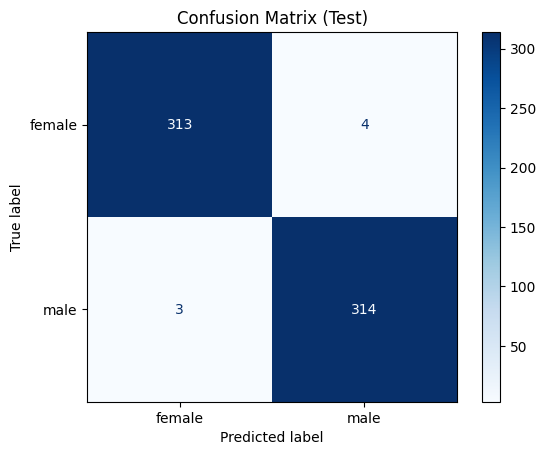

In [10]:
# Evaluasi akhir (test set dipakai sekali di sini)
final = Pipeline([('scaler', StandardScaler()),
                  ('knn', KNeighborsClassifier(n_neighbors=best_k))])
final.fit(X_train[fitur_final], y_train)
y_pred = final.predict(X_test[fitur_final])

print('Fitur :', fitur_final)
print('k     :', best_k)
print('Akurasi test:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['female', 'male']))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['female', 'male']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test)')
plt.show()

# Penjelasan Pengerjaan Tugas Lab 1: Klasifikasi Suara Male/Female dengan kNN

**Dataset:** `voice.csv` (3168 sampel, 20 fitur akustik, label `male`/`female`).
Kelas seimbang (male 1584, female 1584) dan tidak ada missing value.

**Prinsip yang dipakai di seluruh percobaan:**
- Pemilihan fitur dan nilai *k* dilakukan dengan **5-fold Cross-Validation pada data train saja**.
- **Data test hanya dipakai untuk evaluasi akhir**, sehingga hasilnya tidak bias.
- `StandardScaler` dan pemilihan fitur dimasukkan ke dalam **Pipeline** agar tidak terjadi *data leakage*.

---

## Soal 1: Model Klasifikasi kNN

**Langkah pengerjaan:**
1. **Load dan inspeksi data.** Dataset dimuat dengan `pandas`, lalu dicek ukuran (3168 baris, 21 kolom), distribusi kelas, dan missing value.
2. **Encoding label.** `female = 0`, `male = 1`, karena algoritma membutuhkan label numerik.
3. **Split data 80:20** (2534 train, 634 test) dengan `stratify=y` agar proporsi male:female tetap sama, dan `random_state=42` agar hasil dapat direproduksi.
4. **Standardisasi dengan `StandardScaler`.** kNN bekerja berdasarkan jarak, sehingga fitur berskala besar akan mendominasi fitur berskala kecil. Scaler ditaruh di dalam `Pipeline` agar pada setiap fold hanya "belajar" dari data latih fold tersebut.
5. **Cross-Validation.** `StratifiedKFold` 5 lipatan membuat estimasi performa lebih stabil dibanding satu kali split.
6. **Model baseline:** `KNeighborsClassifier` dengan semua 20 fitur dan k = 5.

**Hasil baseline:** akurasi CV = **0,9696**, akurasi test = **0,9763**.

---

## Soal 2: Fitur Paling Optimal

**a. Ranking fitur** (dihitung hanya dari data train):
- **F-score (ANOVA):** mengukur seberapa jauh rata-rata fitur antar kelas dibanding variasi di dalam kelas.
- **Mutual Information:** mengukur ketergantungan fitur terhadap label, termasuk hubungan non-linear.

Temuan:
- `meanfun` (rata-rata frekuensi fundamental) adalah fitur terkuat (F ≈ 5698), jauh di atas `IQR` (≈ 1566), `Q25`, `sp.ent`, dan `sd`. Ini masuk akal karena pitch suara pria umumnya lebih rendah dibanding wanita.
- `meanfreq` dan `centroid` memiliki skor identik (≈ 324,44), artinya keduanya redundan.
- `modindx`, `skew`, dan `Q75` memiliki skor sangat kecil sehingga kurang informatif.

**b. Metode A, SelectKBest.** Untuk n = 1 sampai 20, diambil n fitur dengan F-score tertinggi, lalu kNN (k = 5) dievaluasi dengan 5-fold CV. `SelectKBest` dimasukkan ke dalam Pipeline agar seleksi diulang di setiap fold dan tidak ada kebocoran data. Akurasi CV naik hingga puncaknya **0,9799 pada 6 fitur** (`sd`, `Q25`, `IQR`, `sp.ent`, `sfm`, `meanfun`), lalu menurun hingga 0,9696 saat semua fitur dipakai.

**c. Metode B, Forward Selection.** `SequentialFeatureSelector` memulai dari nol fitur, lalu menambahkan satu fitur yang paling meningkatkan akurasi CV pada tiap putaran, dan berhenti ketika peningkatan kurang dari 0,001. Berbeda dengan Metode A yang menilai fitur satu per satu, metode ini menilai **kombinasi** fitur dengan model kNN yang sama. Fitur terpilih: **`IQR`, `sfm`, `mode`, `meanfun`**.

**d. Perbandingan kandidat** (kNN, k = 5):

| Kandidat | Jumlah Fitur | Akurasi CV | Akurasi Test |
|---|---|---|---|
| Semua fitur | 20 | 0,9696 | 0,9763 |
| SelectKBest (top-6) | 6 | 0,9799 | 0,9858 |
| **Forward Selection** | **4** | **0,9807** | **0,9890** |

Pemenang ditentukan dari akurasi CV, bukan dari akurasi test, agar data test tidak ikut memengaruhi keputusan.

**Jawaban Soal 2: fitur paling optimal adalah `IQR`, `sfm`, `mode`, dan `meanfun`.**

Alasan dan analisis:
- Memakai semua fitur justru memberi hasil terendah. Fitur yang redundan dan tidak informatif menambah dimensi dan *noise* pada perhitungan jarak kNN (*curse of dimensionality*).
- `sfm` dan `mode` tidak berada di peringkat teratas F-score, tetapi melengkapi `meanfun` dan `IQR`. Jadi kombinasi fitur yang saling melengkapi bisa lebih baik daripada sekadar mengambil fitur dengan skor individu tertinggi.
- Selisih 4 fitur dan 6 fitur sangat kecil (sekitar 0,001) dan berada dalam rentang simpangan baku CV, sehingga keduanya praktis setara. Empat fitur dipilih karena CV tertinggi dan model paling ringkas.
- Karena Forward Selection memilih fitur berdasarkan CV yang sama, angka CV-nya sedikit optimistis. Angka test (0,9890) yang konsisten menjadi konfirmasi.

---

## Soal 3: Nilai k Terbaik

Dengan 4 fitur terpilih, nilai k diuji dari 1 sampai 30. Untuk tiap k dihitung akurasi **train**, **CV (5-fold)**, dan **test**. Kriteria: k terbaik adalah k dengan akurasi CV tertinggi.

| k | Train | CV | Test |
|---|---|---|---|
| 1 | 1,0000 | 0,9708 | 0,9826 |
| 3 | 0,9870 | 0,9787 | 0,9874 |
| **5** | **0,9838** | **0,9807** | **0,9890** |
| 10 | 0,9811 | 0,9744 | 0,9874 |
| 30 | 0,9708 | 0,9688 | 0,9763 |

**Jawaban Soal 3: k terbaik = 5** (akurasi CV = 0,9807).

Alasan berdasarkan grafik Nilai k vs Akurasi:
1. **k sangat kecil (k = 1) mengalami overfitting.** Akurasi train 1,000 tetapi CV hanya 0,9708. Model hanya meniru satu tetangga terdekat sehingga sangat sensitif terhadap noise.
2. **k besar (k > 6) mengalami underfitting.** Akurasi CV turun terus hingga sekitar 0,968 pada k = 30, dan akurasi train ikut turun. Batas keputusan menjadi terlalu halus dan kehilangan pola data.
3. **k = 5 adalah titik seimbang.** Berada di puncak kurva CV, dengan selisih train dan CV kecil (sekitar 0,003), sehingga model stabil dan mampu generalisasi.
4. Nilai k dipilih dengan CV, bukan dengan test, agar akurasi test tetap menjadi estimasi yang jujur.

---

## Evaluasi Akhir Model

Model final (4 fitur, k = 5) dilatih pada seluruh data train, lalu diuji sekali pada data test (634 sampel).

- **Akurasi test = 0,9890 (98,9%)**
- Precision, recall, dan F1-score = **0,99** untuk kedua kelas

| | Prediksi female | Prediksi male |
|---|---|---|
| **Aktual female** | 313 | 4 |
| **Aktual male** | 3 | 314 |

Hanya 7 kesalahan dari 634 data, dan hampir seimbang di kedua kelas, sehingga model tidak bias ke salah satu jenis suara.

---

## Kesimpulan

1. **Soal 1:** Model kNN berhasil dibuat untuk mengklasifikasikan suara male dan female. Baseline dengan 20 fitur dan k = 5 menghasilkan akurasi test 97,63%.
2. **Soal 2:** Fitur paling optimal adalah **`IQR`, `sfm`, `mode`, dan `meanfun`**, dengan akurasi CV 98,07% dan akurasi test 98,90%. Fitur `meanfun` paling berpengaruh. Penggunaan semua 20 fitur justru memberi hasil terendah.
3. **Soal 3:** Dengan fitur terpilih, **k terbaik adalah 5**. k yang lebih kecil menyebabkan overfitting dan k yang lebih besar menyebabkan underfitting, sehingga k = 5 memberi keseimbangan terbaik antara bias dan varians.

Model akhir mencapai **akurasi 98,9%** pada data test, lebih baik dari baseline dan lebih sederhana karena hanya memakai 4 fitur.